# Brain Tumor MRI Classification + XAI
Step 1: Clean pipeline port — dataset → crop → EfficientNet-B0 → train/load → eval.
Run top to bottom in Colab (GPU runtime).

In [4]:
!pip install -q opendatasets torch torchvision opencv-python-headless scikit-learn

In [5]:
import os
import cv2
import json
import numpy as np
import torch
import torch.nn as nn
import opendatasets as od
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torch.optim.lr_scheduler import StepLR
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1. Dataset download

In [6]:
# Requires kaggle.json (upload when prompted, or place in ~/.kaggle/)
DATASET_URL = "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset"
od.download(DATASET_URL)

DATA_ROOT = "brain-tumor-mri-dataset"
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR = os.path.join(DATA_ROOT, "Testing")
CLASSES = sorted(os.listdir(TRAIN_DIR))
print("Classes:", CLASSES)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Bhavnish000
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:08<00:00, 19.4MB/s]



Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [7]:
def crop_image(image, add_pixels=0):
    """Crop MRI scan to brain region using contour detection on the largest object."""
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY) if image.ndim == 3 else image
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return image  # fallback: no crop if contour detection fails

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    x1 = max(x - add_pixels, 0)
    y1 = max(y - add_pixels, 0)
    x2 = min(x + w + add_pixels, image.shape[1])
    y2 = min(y + h + add_pixels, image.shape[0])

    return image[y1:y2, x1:x2]


def load_and_crop(path, size=240):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image(img)
    img = cv2.resize(img, (size, size))
    return img

## 3. Dataset class

In [8]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, size=240):
        self.samples = []
        self.transform = transform
        self.size = size
        for label_idx, cls in enumerate(classes):
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                self.samples.append((os.path.join(cls_dir, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = load_and_crop(path, self.size)  # numpy RGB, uint8
        if self.transform:
            img = self.transform(img)
        return img, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_train_ds = BrainTumorDataset(TRAIN_DIR, CLASSES, transform=train_transform)
test_ds = BrainTumorDataset(TEST_DIR, CLASSES, transform=eval_transform)

# Small held-out val split from training data for model selection during training
val_size = int(0.1 * len(full_train_ds))
train_size = len(full_train_ds) - val_size
train_ds, val_ds = random_split(full_train_ds, [train_size, val_size],
                                 generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 5040 | Val: 560 | Test: 1600


## 4. Model — EfficientNet-B0

In [9]:
def build_model(num_classes=len(CLASSES)):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model.to(device)

model = build_model()

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 195MB/s]


## 5. Train — or load an existing checkpoint

In [10]:
os.makedirs("saved_model", exist_ok=True)
CKPT_PATH = "saved_model/efficientnet_b0_brain_tumor.pt"

LOAD_EXISTING = False  # flip to True once you have a checkpoint to skip retraining

if LOAD_EXISTING and os.path.exists(CKPT_PATH):
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))
    print("Loaded checkpoint from", CKPT_PATH)
else:
    EPOCHS = 10
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = StepLR(optimizer, step_size=4, gamma=0.5)

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_ds)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
        val_loss /= len(val_ds)
        val_acc = correct / len(val_ds)

        scheduler.step()
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.4f} | "
              f"val_loss {val_loss:.4f} | val_acc {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), CKPT_PATH)

    print("Best val acc:", best_val_acc, "| checkpoint saved to", CKPT_PATH)
    model.load_state_dict(torch.load(CKPT_PATH, map_location=device))  # reload best

Epoch 1/10 | train_loss 0.4492 | val_loss 0.1553 | val_acc 0.9446
Epoch 2/10 | train_loss 0.1352 | val_loss 0.0671 | val_acc 0.9732
Epoch 3/10 | train_loss 0.0703 | val_loss 0.0580 | val_acc 0.9821
Epoch 4/10 | train_loss 0.0454 | val_loss 0.0259 | val_acc 0.9946
Epoch 5/10 | train_loss 0.0307 | val_loss 0.0393 | val_acc 0.9857
Epoch 6/10 | train_loss 0.0231 | val_loss 0.0379 | val_acc 0.9857
Epoch 7/10 | train_loss 0.0178 | val_loss 0.0451 | val_acc 0.9857
Epoch 8/10 | train_loss 0.0210 | val_loss 0.0332 | val_acc 0.9875
Epoch 9/10 | train_loss 0.0140 | val_loss 0.0300 | val_acc 0.9911
Epoch 10/10 | train_loss 0.0130 | val_loss 0.0366 | val_acc 0.9857
Best val acc: 0.9946428571428572 | checkpoint saved to saved_model/efficientnet_b0_brain_tumor.pt


## 6. Evaluation — confusion matrix + classification report

              precision    recall  f1-score   support

      glioma     0.9940    0.8300    0.9046       400
  meningioma     0.8834    0.9850    0.9314       400
     notumor     0.9615    1.0000    0.9804       400
   pituitary     0.9876    0.9975    0.9925       400

    accuracy                         0.9531      1600
   macro avg     0.9566    0.9531    0.9523      1600
weighted avg     0.9566    0.9531    0.9523      1600



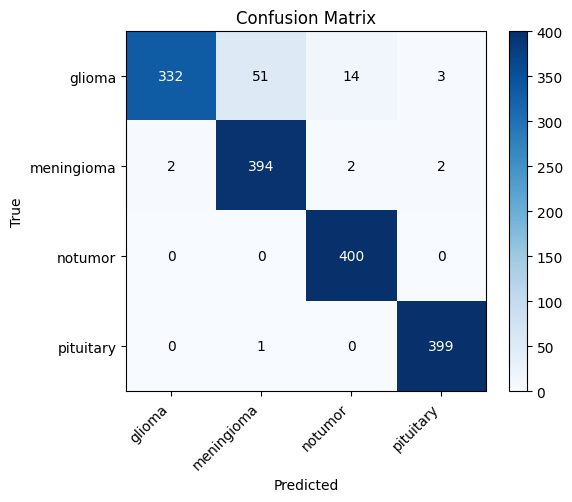

In [11]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix")
plt.colorbar(im)
plt.tight_layout()
plt.savefig("saved_model/confusion_matrix.png", dpi=150)
plt.show()

Checkpoint is at `saved_model/efficientnet_b0_brain_tumor.pt`, ready for Step 2 (Grad-CAM refactor).
Set `LOAD_EXISTING = True` on reruns once this checkpoint exists so you don't retrain from scratch.

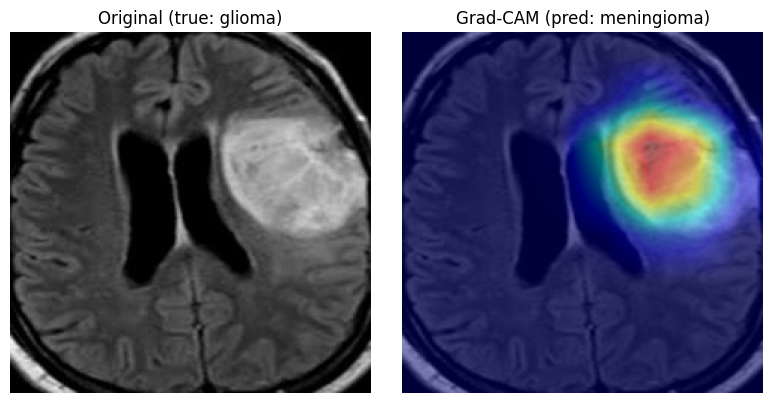

In [15]:
def denormalize(img_tensor):
    """Undo ImageNet normalization for display purposes."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def overlay_heatmap(img_np, cam, alpha=0.45):
    """Blend a [0,1]-normalized cam onto a [0,1] RGB image."""
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255
    overlay = alpha * heatmap + (1 - alpha) * img_np
    return np.clip(overlay, 0, 1)


sample_img, sample_label = test_ds[0]
sample_input = sample_img.unsqueeze(0).to(device)

cam, pred_class = generate_gradcam(model, sample_input, TARGET_LAYER)
img_np = denormalize(sample_img)
overlay = overlay_heatmap(img_np, cam)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_np); axes[0].set_title(f"Original (true: {CLASSES[sample_label]})"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].set_title(f"Grad-CAM (pred: {CLASSES[pred_class]})"); axes[1].axis("off")
plt.tight_layout()
plt.show()

In [16]:
!pip install -q captum

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 24.8 MB/s eta 0:00:00


In [17]:
from captum.attr import IntegratedGradients

def generate_ig(model, image_tensor, target_class, n_steps=50, baseline=None):
    """
    Compute an Integrated Gradients attribution map for a single image.

    model: the trained classifier
    image_tensor: normalized input tensor, shape (1, C, H, W), already on `device`
    target_class: int class index to explain (use the same class Grad-CAM explained,
                   for a fair side-by-side comparison)
    n_steps: number of interpolation steps between baseline and input (more = smoother, slower)
    baseline: reference input representing "no information"; defaults to an all-zero
              (black) image, the standard choice for IG on images

    Returns: (attr_map, delta) where attr_map is a (H, W) numpy array normalized to [0, 1],
             and delta is Captum's convergence-delta diagnostic — should be small (~0),
             large delta means n_steps should be increased
    """
    model.eval()
    ig = IntegratedGradients(model)

    if baseline is None:
        baseline = torch.zeros_like(image_tensor)

    attributions, delta = ig.attribute(
        image_tensor,
        baseline,
        target=target_class,
        n_steps=n_steps,
        return_convergence_delta=True,
    )

    attr = attributions.squeeze().cpu().detach().numpy()   # (C, H, W)
    attr = np.transpose(attr, (1, 2, 0))                    # (H, W, C)
    attr_map = np.sum(np.abs(attr), axis=2)                 # collapse channels: magnitude of attribution per pixel
    attr_map = (attr_map - attr_map.min()) / (attr_map.max() - attr_map.min() + 1e-8)
    return attr_map, delta.item()

Convergence delta: -0.122333  (should be close to 0)


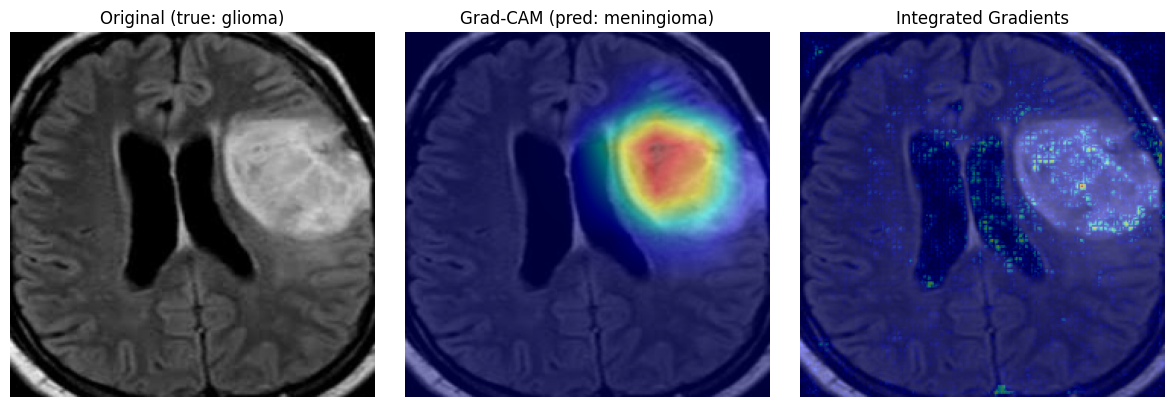

In [18]:
ig_map, delta = generate_ig(model, sample_input, target_class=pred_class)
print(f"Convergence delta: {delta:.6f}  (should be close to 0)")

ig_overlay = overlay_heatmap(img_np, ig_map)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np); axes[0].set_title(f"Original (true: {CLASSES[sample_label]})"); axes[0].axis("off")
axes[1].imshow(overlay); axes[1].set_title(f"Grad-CAM (pred: {CLASSES[pred_class]})"); axes[1].axis("off")
axes[2].imshow(ig_overlay); axes[2].set_title("Integrated Gradients"); axes[2].axis("off")
plt.tight_layout()
plt.show()

In [19]:
import random

def find_examples(model, dataset, n_correct=4, n_incorrect=1, seed=42):
    """Scan the dataset for a mix of correctly and incorrectly classified examples."""
    rng = random.Random(seed)
    indices = list(range(len(dataset)))
    rng.shuffle(indices)

    correct, incorrect = [], []
    model.eval()
    with torch.no_grad():
        for idx in indices:
            if len(correct) >= n_correct and len(incorrect) >= n_incorrect:
                break
            img, label = dataset[idx]
            inp = img.unsqueeze(0).to(device)
            pred = model(inp).argmax(dim=1).item()
            if pred == label and len(correct) < n_correct:
                correct.append(idx)
            elif pred != label and len(incorrect) < n_incorrect:
                incorrect.append(idx)
    return correct + incorrect  # misclassified example(s) last, easy to spot in the grid

Selected test-set indices: [856, 549, 970, 111, 462]


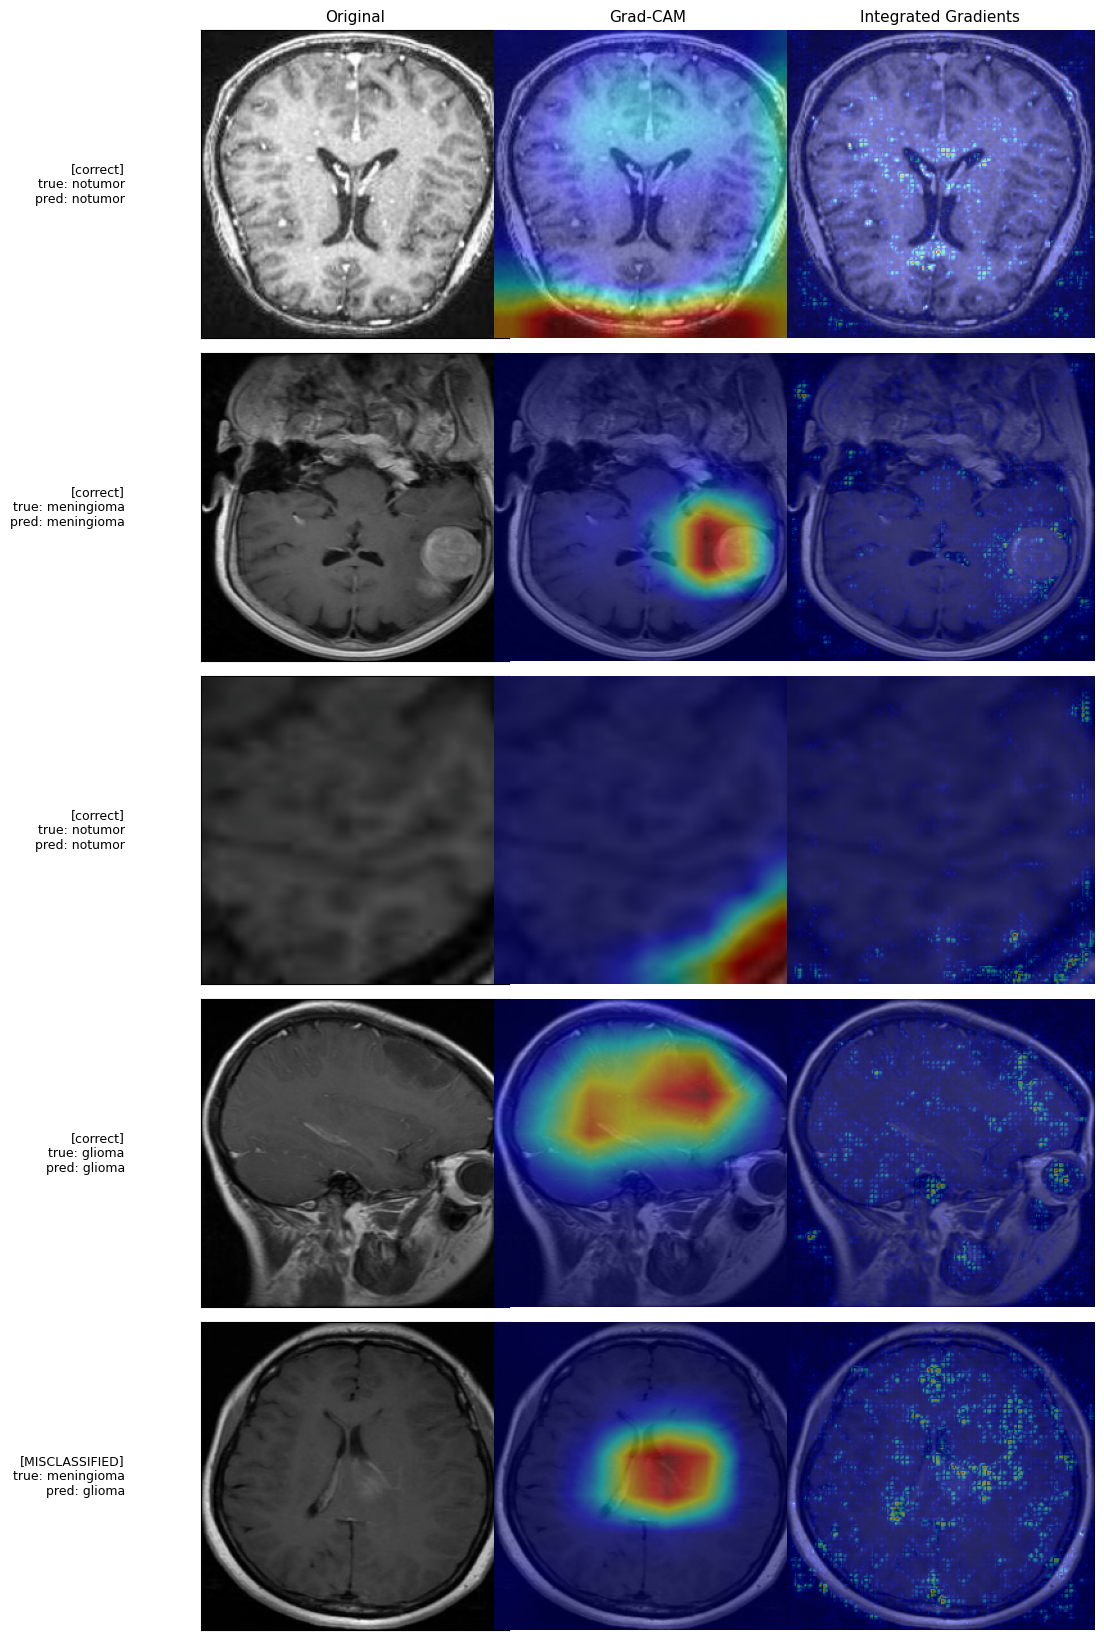

Saved to saved_model/xai_comparison_grid.png


In [20]:
example_indices = find_examples(model, test_ds, n_correct=4, n_incorrect=1)
print("Selected test-set indices:", example_indices)

fig, axes = plt.subplots(len(example_indices), 3, figsize=(11, 3.3 * len(example_indices)))

for row, idx in enumerate(example_indices):
    img, label = test_ds[idx]
    inp = img.unsqueeze(0).to(device)

    cam, pred = generate_gradcam(model, inp, TARGET_LAYER)
    ig_map, delta = generate_ig(model, inp, target_class=pred, n_steps=100)  # more steps = tighter convergence

    img_np = denormalize(img)
    cam_overlay = overlay_heatmap(img_np, cam)
    ig_overlay = overlay_heatmap(img_np, ig_map)

    is_correct = pred == label
    tag = "correct" if is_correct else "MISCLASSIFIED"
    row_label = f"[{tag}]\ntrue: {CLASSES[label]}\npred: {CLASSES[pred]}"

    axes[row, 0].imshow(img_np)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(row_label, fontsize=9, rotation=0, labelpad=55, ha="right", va="center")

    axes[row, 1].imshow(cam_overlay); axes[row, 1].axis("off")
    axes[row, 2].imshow(ig_overlay); axes[row, 2].axis("off")

    if row == 0:
        axes[row, 0].set_title("Original", fontsize=11)
        axes[row, 1].set_title("Grad-CAM", fontsize=11)
        axes[row, 2].set_title("Integrated Gradients", fontsize=11)

plt.tight_layout()
plt.savefig("saved_model/xai_comparison_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to saved_model/xai_comparison_grid.png")